In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/anurag-bhattacharjee/Credit-Card-Dataset/main/CC%20GENERAL.csv"
df = pd.read_csv(url)

In [3]:
df.shape

(8950, 18)

In [4]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [6]:
# ============================================================
# MISSING VALUES
# ============================================================

In [7]:
# Check null counts and percentages
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df['missing_count'] > 0]

,missing_count,missing_pct
CREDIT_LIMIT,1,0.011173
MINIMUM_PAYMENTS,313,3.497207


In [8]:
# ============================================================
# DROP IDENTIFIER COLUMN
# ============================================================

In [9]:
# CUST_ID carries no behavioral information, drop it
df = df.drop(columns=['CUST_ID'])

In [10]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [12]:
# ============================================================
# SKEWNESS CHECK
# ============================================================

In [13]:
# High skew is expected here — most financial/behavioral columns
# (BALANCE, PURCHASES, CASH_ADVANCE etc.) are right-skewed by nature
skew_vals = df.skew().sort_values(ascending=False)
skew_vals

MINIMUM_PAYMENTS                    13.622797
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522464
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64

In [14]:
# ============================================================
# DISTRIBUTION PLOTS
# ============================================================

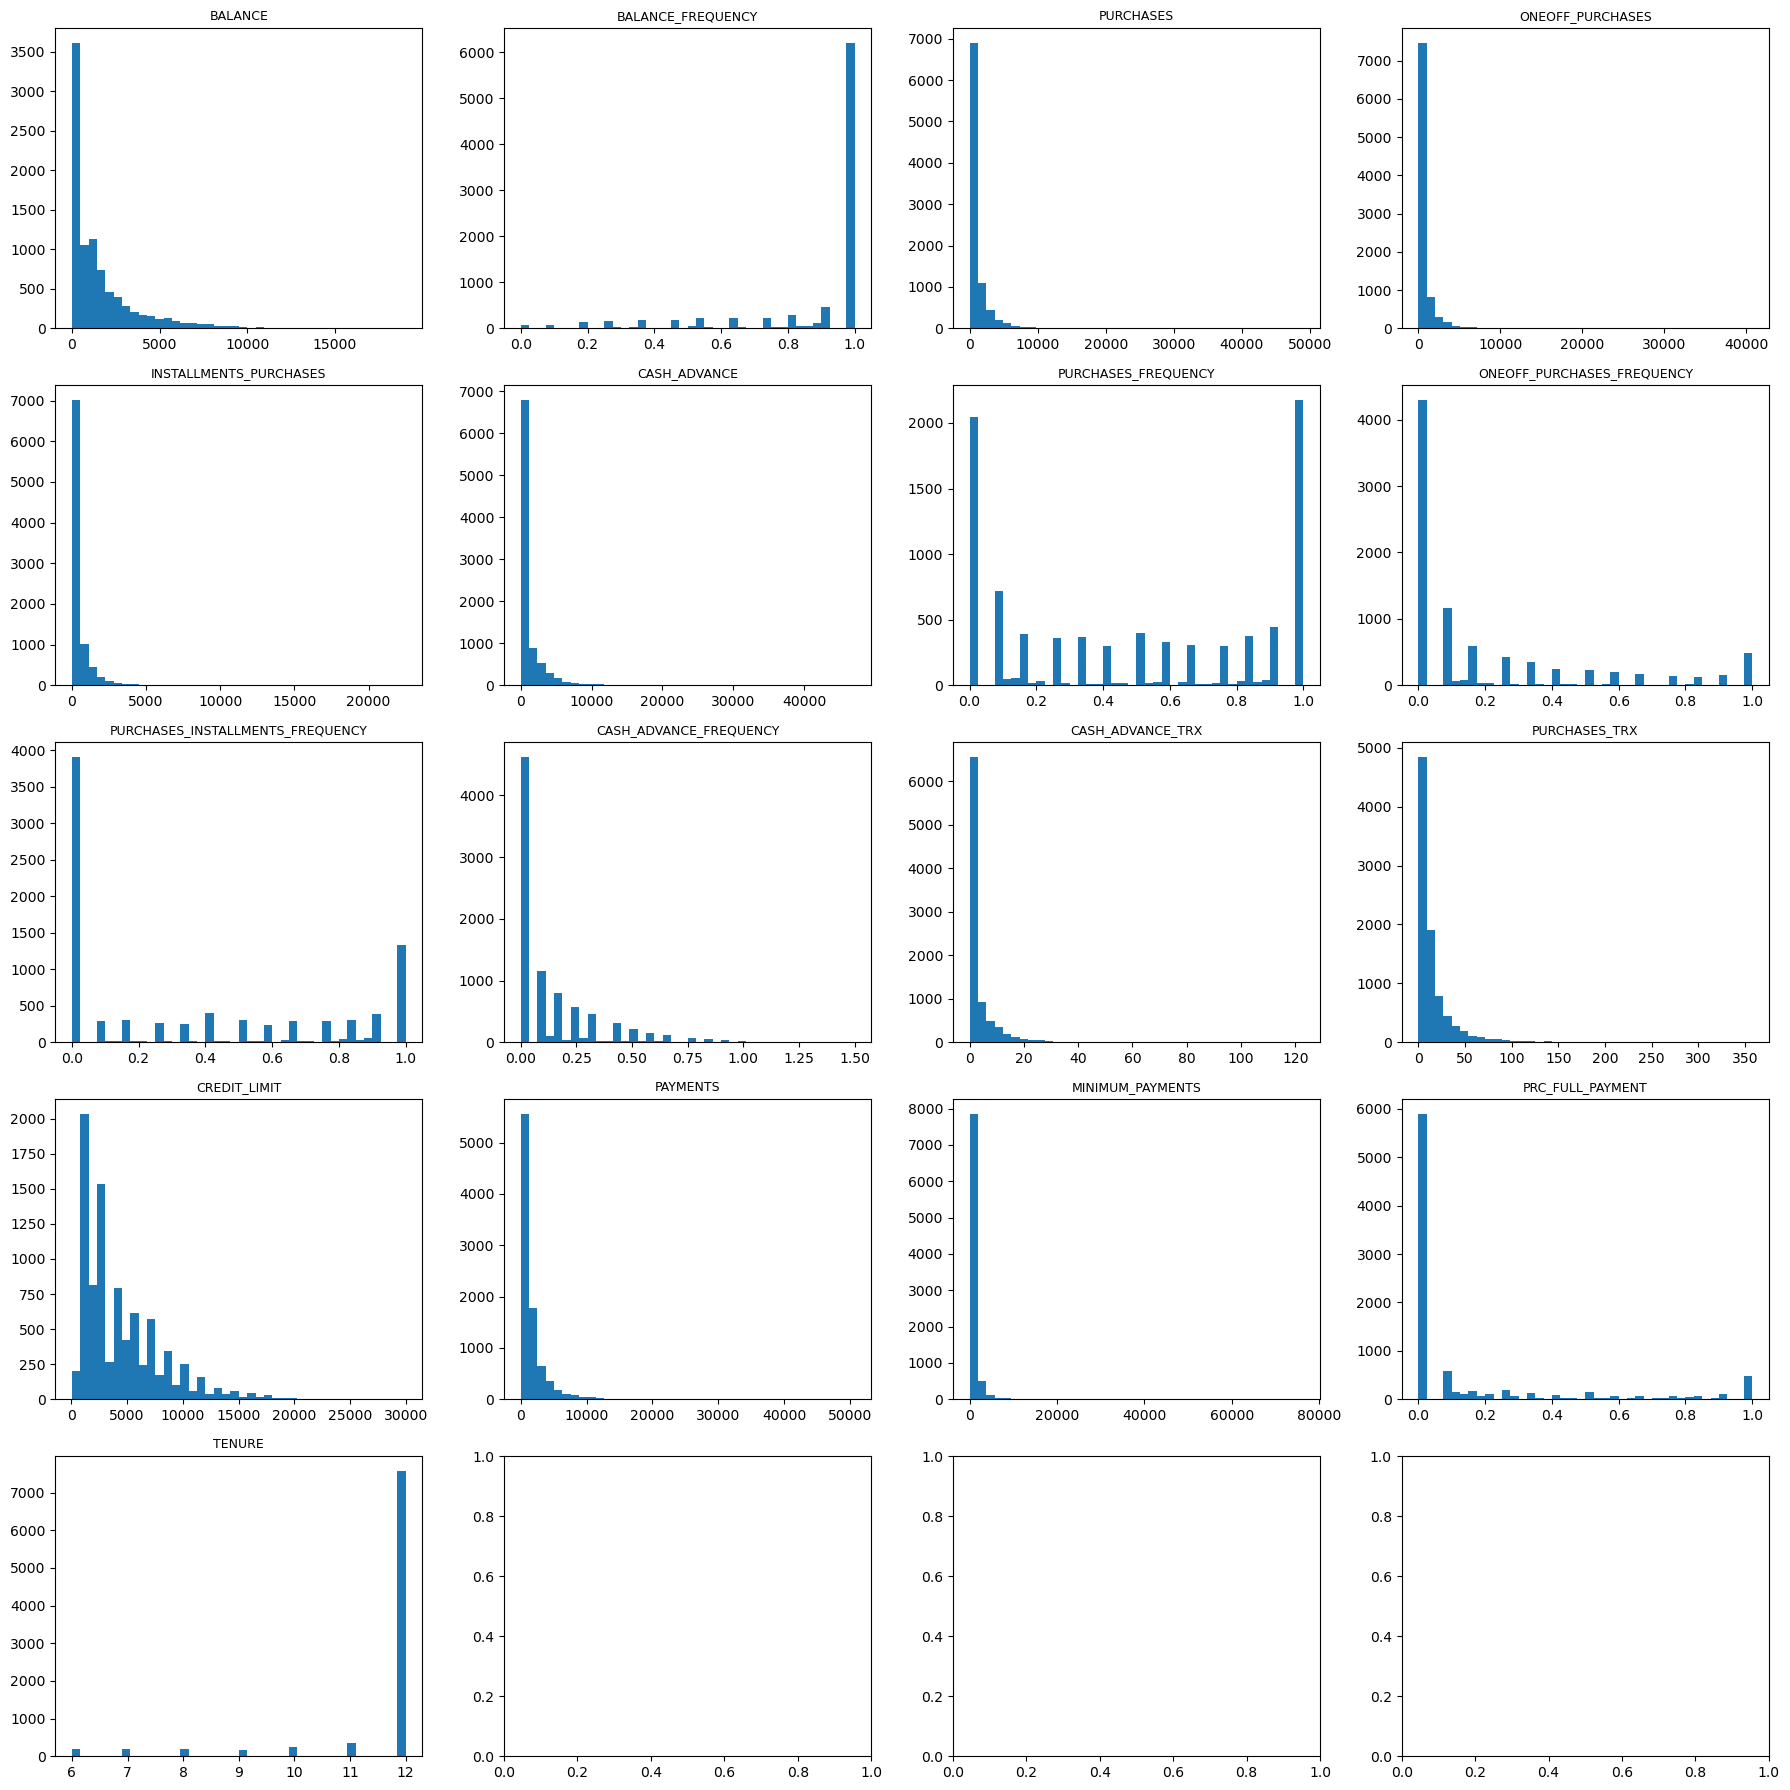

In [15]:
fig, axes = plt.subplots(5,4, figsize=(18,18))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col].dropna(), bins=40)
    axes[i].set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# CHECK FOR REMAINING NANS AFTER TRANSFORM
# ============================================================

In [17]:
skewed_cols = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
    'PAYMENTS', 'MINIMUM_PAYMENTS', 'CREDIT_LIMIT'
]

df[skewed_cols].isnull().sum()

BALANCE                     0
PURCHASES                   0
ONEOFF_PURCHASES            0
INSTALLMENTS_PURCHASES      0
CASH_ADVANCE                0
CASH_ADVANCE_TRX            0
PURCHASES_TRX               0
PAYMENTS                    0
MINIMUM_PAYMENTS          313
CREDIT_LIMIT                1
dtype: int64

In [18]:
# ============================================================
# MISSING VALUE IMPUTATION (before Yeo-Johnson)
# ============================================================

In [19]:
# Median imputation — behavioral/financial columns, median is robust to outliers
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

# Verify no nulls remain
df.isnull().sum().sum()

np.int64(0)

In [20]:
# ============================================================
# YEO-JOHNSON TRANSFORM (skewed monetary/count columns only)
# ============================================================

In [21]:
from sklearn.preprocessing import PowerTransformer

In [22]:
# Columns with strong right-skew identified in skewness check

pt = PowerTransformer(method='yeo-johnson', standardize=False)
df[skewed_cols] = pt.fit_transform(df[skewed_cols])

# Re-check skewness after transform
df[skewed_cols].skew().sort_values(ascending=False)

CASH_ADVANCE_TRX          0.392581
CASH_ADVANCE              0.188413
PAYMENTS                  0.124631
ONEOFF_PURCHASES          0.115147
PURCHASES_TRX             0.006058
CREDIT_LIMIT             -0.009651
INSTALLMENTS_PURCHASES   -0.014843
MINIMUM_PAYMENTS         -0.029965
BALANCE                  -0.119428
PURCHASES                -0.178677
dtype: float64

In [23]:
# ============================================================
# SKEW CHECK — remaining (non-transformed) columns
# ============================================================

In [24]:
# Frequency/ratio columns (0-1 range) and TENURE were NOT Yeo-Johnson'd
remaining_cols = [col for col in df.columns if col not in skewed_cols]
df[remaining_cols].skew().sort_values(ascending=False)

PRC_FULL_PAYMENT                    1.942820
CASH_ADVANCE_FREQUENCY              1.828686
ONEOFF_PURCHASES_FREQUENCY          1.535613
PURCHASES_INSTALLMENTS_FREQUENCY    0.509201
PURCHASES_FREQUENCY                 0.060164
BALANCE_FREQUENCY                  -2.023266
TENURE                             -2.943017
dtype: float64

In [25]:
# ============================================================
# TENURE VALUE COUNTS
# ============================================================

In [26]:
# Check how concentrated TENURE really is
df['TENURE'].value_counts().sort_index()

TENURE
6      204
7      190
8      196
9      175
10     236
11     365
12    7584
Name: count, dtype: int64

In [27]:
# ============================================================
# YEO-JOHNSON — additional moderately-skewed ratio columns
# ============================================================

In [28]:
other_skewed_cols = [
    'PRC_FULL_PAYMENT', 'CASH_ADVANCE_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY', 'BALANCE_FREQUENCY'
]

pt2 = PowerTransformer(method='yeo-johnson', standardize=False)
df[other_skewed_cols] = pt2.fit_transform(df[other_skewed_cols])

# Verify improvement
df[other_skewed_cols].skew().sort_values(ascending=False)

PRC_FULL_PAYMENT              0.963939
ONEOFF_PURCHASES_FREQUENCY    0.541358
CASH_ADVANCE_FREQUENCY        0.506434
BALANCE_FREQUENCY            -1.118938
dtype: float64

In [29]:
df['BALANCE_FREQUENCY'].describe()

count    8950.000000
mean      142.839838
std        71.505556
min         0.000000
25%       100.010962
50%       187.786569
75%       187.786569
max       187.786569
Name: BALANCE_FREQUENCY, dtype: float64

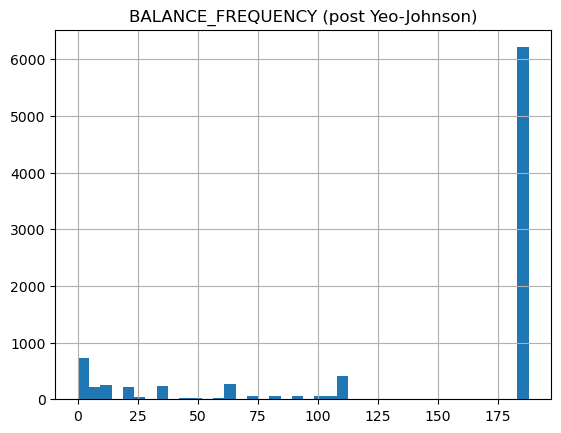

In [30]:
df['BALANCE_FREQUENCY'].hist(bins=40)
plt.title('BALANCE_FREQUENCY (post Yeo-Johnson)')
plt.show()

In [31]:
# ============================================================
# CORRELATION MATRIX
# ============================================================

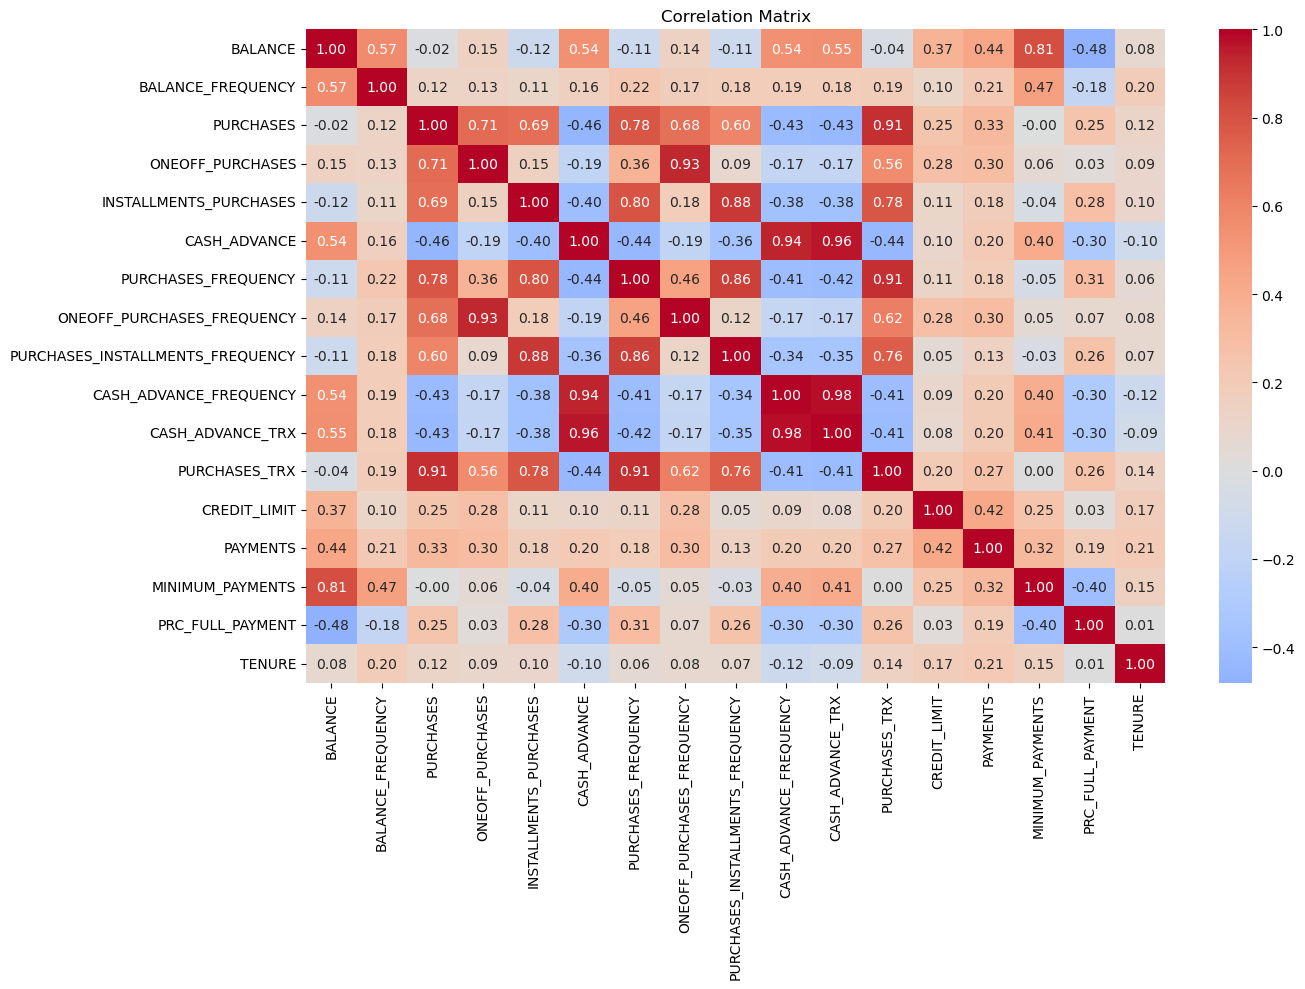

In [32]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# VIF CHECK
# ============================================================

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [35]:
X = add_constant(df)  # intercept eklenmeden VIF yapay şekilde şişer

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Drop the constant row from the output, we don't need to interpret it
vif_data = vif_data[vif_data['feature'] != 'const'].sort_values('VIF', ascending=False)
vif_data

,feature,VIF
11,CASH_ADVANCE_TRX,41.909142
10,CASH_ADVANCE_FREQUENCY,26.913960
12,PURCHASES_TRX,17.629105
6,CASH_ADVANCE,14.471765
7,PURCHASES_FREQUENCY,14.432356
8,ONEOFF_PURCHASES_FREQUENCY,13.943600
4,ONEOFF_PURCHASES,13.839800
3,PURCHASES,13.077196
9,PURCHASES_INSTALLMENTS_FREQUENCY,11.298563
1,BALANCE,7.258963


In [36]:
# ============================================================
# ITERATIVE VIF ELIMINATION (threshold = 10)
# ============================================================

In [37]:
def calculate_vif(data):
    X = add_constant(data)
    vif = pd.DataFrame()
    vif['feature'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif[vif['feature'] != 'const'].sort_values('VIF', ascending=False)

In [38]:
df_vif = df.copy()
dropped_features = []

while True:
    vif_result = calculate_vif(df_vif)
    max_vif = vif_result.iloc[0]
    if max_vif['VIF'] > 10:
        feature_to_drop = max_vif['feature']
        dropped_features.append((feature_to_drop, max_vif['VIF']))
        df_vif = df_vif.drop(columns=[feature_to_drop])
        print(f"Dropped: {feature_to_drop} (VIF={max_vif['VIF']:.2f})")
    else:
        break

print("\nRemaining features VIF:")
calculate_vif(df_vif)

Dropped: CASH_ADVANCE_TRX (VIF=41.91)
Dropped: PURCHASES_TRX (VIF=17.62)
Dropped: ONEOFF_PURCHASES (VIF=13.33)

Remaining features VIF:


,feature,VIF
8,PURCHASES_INSTALLMENTS_FREQUENCY,9.825129
6,PURCHASES_FREQUENCY,9.631364
5,CASH_ADVANCE,9.300506
9,CASH_ADVANCE_FREQUENCY,8.788535
1,BALANCE,7.250581
3,PURCHASES,6.216288
4,INSTALLMENTS_PURCHASES,6.038464
7,ONEOFF_PURCHASES_FREQUENCY,3.496730
12,MINIMUM_PAYMENTS,3.237398
11,PAYMENTS,2.095901


In [39]:
# ============================================================
# APPLY VIF-BASED FEATURE ELIMINATION
# ============================================================

In [40]:
df = df_vif.copy()
df.shape

(8950, 14)

In [41]:
# ============================================================
# STANDARD SCALER
# ============================================================

In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

df_scaled.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
BALANCE,-4.445854e-17,1.000056,-2.120305,2.731227
BALANCE_FREQUENCY,-4.699903e-16,1.000056,-1.997716,0.628612
PURCHASES,1.238488e-16,1.000056,-1.505149,3.559070
INSTALLMENTS_PURCHASES,7.184818e-17,1.000056,-1.085422,2.212015
CASH_ADVANCE,1.381390e-16,1.000056,-0.944538,1.729923
PURCHASES_FREQUENCY,9.328354e-17,1.000056,-1.221758,1.269843
ONEOFF_PURCHASES_FREQUENCY,-2.540488e-17,1.000056,-0.903315,1.732554
PURCHASES_INSTALLMENTS_FREQUENCY,5.716098e-17,1.000056,-0.916995,1.599199
CASH_ADVANCE_FREQUENCY,-9.804696e-17,1.000056,-0.883204,1.902718
CREDIT_LIMIT,-4.826927e-16,1.000056,-4.573150,2.851804


In [44]:
# ============================================================
# PCA — DIMENSIONALITY REDUCTION
# ============================================================

In [45]:
from sklearn.decomposition import PCA

In [46]:
# First check explained variance across all components
pca_full = PCA()
pca_full.fit(df_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(explained_var))],
    'explained_variance': explained_var,
    'cumulative_variance': cumulative_var
})

,component,explained_variance,cumulative_variance
0,PC1,0.321016,0.321016
1,PC2,0.237596,0.558612
2,PC3,0.094934,0.653546
3,PC4,0.082731,0.736277
4,PC5,0.073293,0.809570
5,PC6,0.052754,0.862324
6,PC7,0.041727,0.904051
7,PC8,0.036673,0.940724
8,PC9,0.024409,0.965133
9,PC10,0.012448,0.977581


In [47]:
# ============================================================
# PCA — FIT WITH 5 COMPONENTS
# ============================================================

In [48]:
pca = PCA(n_components = 5)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=[f"PC{i+1}" for i in range(5)])

print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")
df_pca.head()

Total explained variance: 0.8096


,PC1,PC2,PC3,PC4,PC5
0,0.040640,-2.756710,-0.608960,0.994109,0.365542
1,-2.830101,0.830416,1.513864,-1.227271,1.510390
2,0.570178,1.214435,0.920476,2.191201,-1.354914
3,-1.443469,-1.073671,0.539882,1.076480,-0.928210
4,-1.053928,-1.197905,-0.245985,1.851057,0.056069


In [49]:
# ============================================================
# COMPONENT LOADINGS — interpret PC1 and PC2
# ============================================================

In [50]:
pc_names = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']

loadings = pd.DataFrame(
    pca.components_.T,
    columns= pc_names,
    index=df.columns
)

In [51]:
# Focus on PC1 and PC2 first (they carry the most information)
loadings[['PC1', 'PC2']].sort_values('PC1', ascending=False)

,PC1,PC2
PURCHASES_FREQUENCY,0.406624,0.171407
PURCHASES,0.381622,0.212771
INSTALLMENTS_PURCHASES,0.380357,0.139859
PURCHASES_INSTALLMENTS_FREQUENCY,0.366847,0.136988
PRC_FULL_PAYMENT,0.235220,-0.126579
ONEOFF_PURCHASES_FREQUENCY,0.196535,0.228521
TENURE,0.057425,0.139800
PAYMENTS,0.046656,0.356657
CREDIT_LIMIT,0.032239,0.291198
BALANCE_FREQUENCY,-0.012764,0.353932


In [52]:
# ============================================================
# PC1 vs PC2 SCATTER (no clustering yet, just shape of data)
# ============================================================

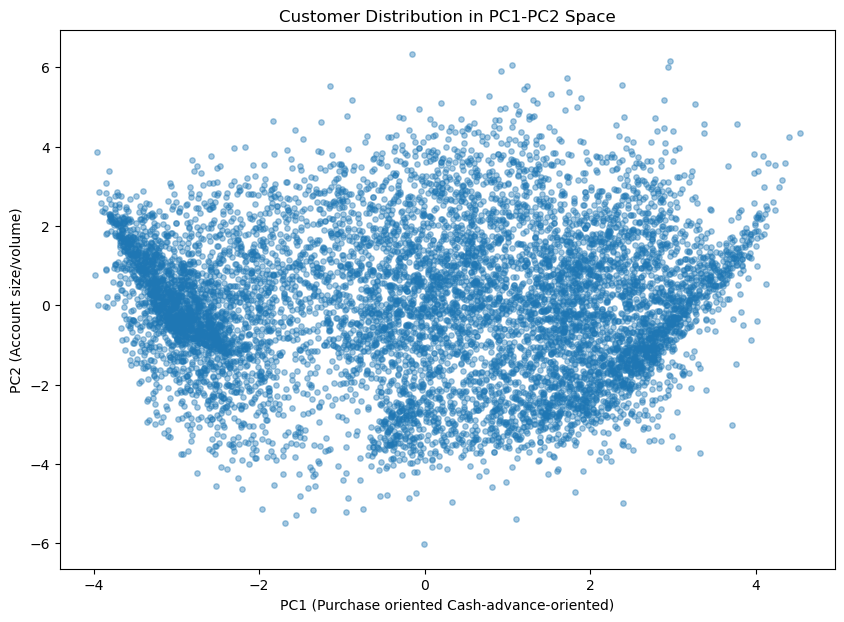

In [53]:
plt.figure(figsize=(10,7))
plt.scatter(df_pca["PC1"], df_pca["PC2"], alpha=0.4, s=15)
plt.xlabel("PC1 (Purchase oriented Cash-advance-oriented)")
plt.ylabel("PC2 (Account size/volume)")
plt.title("Customer Distribution in PC1-PC2 Space")
plt.show()

In [54]:
# ============================================================
# K-DISTANCE PLOT — for eps selection
# ============================================================

In [55]:
from sklearn.neighbors import NearestNeighbors

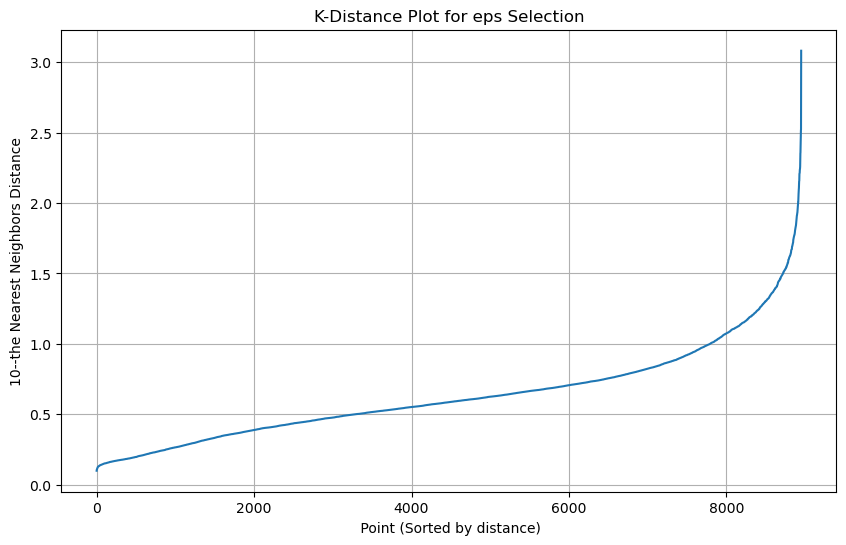

In [56]:
min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(df_pca)
distances, indices = neighbors_fit.kneighbors(df_pca)

k_distances = np.sort(distances[:,-1])

plt.figure(figsize=(10,6))
plt.plot(k_distances)
plt.xlabel(" Point (Sorted by distance)")
plt.ylabel(f"{min_samples}--the Nearest Neighbors Distance")
plt.title("K-Distance Plot for eps Selection")
plt.grid(True)
plt.show()

In [57]:
# ============================================================
# DBSCAN — first attempt
# ============================================================

In [58]:
from sklearn.cluster import DBSCAN

In [59]:

dbscan = DBSCAN(eps=0.8, min_samples=10)
labels = dbscan.fit_predict(df_pca)

# Cluster count (excluding noise) and noise ratio
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print(f"Number of clusters: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(labels)*100:.2f}%)")

unique, counts = np.unique(labels, return_counts=True)
pd.DataFrame({'cluster': unique, 'count': counts}).sort_values('cluster')

Number of clusters: 4
Noise points: 1246 (13.92%)


,cluster,count
0,-1,1246
1,0,7670
2,1,10
3,2,15
4,3,9


In [60]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [61]:
# ============================================================
# DBSCAN — GRID SEARCH (eps x min_samples) with Silhouette Score
# ============================================================

In [62]:
eps_values = np.arange(0.3, 1.3, 0.1)
min_samples_values = [5, 10, 15, 20]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(df_pca)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = n_noise / len(labels) * 100

        # Metrics require at least 2 clusters and are calculated on non-noise points only
        if n_clusters >= 2:
            mask = labels != -1
            try:
                sil_score = silhouette_score(df_pca[mask], labels[mask])
                ch_score = calinski_harabasz_score(df_pca[mask], labels[mask])
                db_score = davies_bouldin_score(df_pca[mask], labels[mask])
            except:
                sil_score = np.nan
                ch_score = np.nan
                db_score = np.nan
        else:
            sil_score = np.nan
            ch_score = np.nan
            db_score = np.nan

        results.append({
            'eps': round(eps, 2),
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'noise_pct': round(noise_pct, 2),
            'silhouette': round(sil_score, 4) if not np.isnan(sil_score) else np.nan,
            'calinski_harabasz': round(ch_score, 2) if not np.isnan(ch_score) else np.nan,
            'davies_bouldin': round(db_score, 4) if not np.isnan(db_score) else np.nan
        })

results_df = pd.DataFrame(results)

# Sort by silhouette score as primary reference
results_df_sorted = results_df.sort_values('silhouette', ascending=False)
results_df_sorted.head(20)

,eps,min_samples,n_clusters,noise_pct,silhouette,calinski_harabasz,davies_bouldin
3,0.3,20,4,87.27,0.7470,2666.43,0.3074
2,0.3,15,7,84.85,0.6220,2065.78,0.3500
7,0.4,20,8,79.41,0.5894,2788.79,0.5093
11,0.5,20,12,66.32,0.3061,2004.09,0.8026
1,0.3,10,15,81.22,0.2997,1335.65,0.7108
6,0.4,15,16,74.59,0.2994,1708.37,0.7219
26,0.9,15,2,12.22,0.2651,37.00,0.7061
23,0.8,20,5,20.15,0.2257,1651.50,0.9859
19,0.7,20,5,31.97,0.2023,1410.51,1.0361
38,1.2,15,2,4.19,0.1904,47.37,0.9518


In [63]:
# ============================================================
# DBSCAN — FINAL MODEL
# ============================================================

In [64]:
dbscan_final = DBSCAN(eps=0.8, min_samples=20)
labels_final = dbscan_final.fit_predict(df_pca)

# Add labels back to original (unscaled, pre-transform interpretation-friendly) dataframe
df_clusters = df.copy()
df_clusters['cluster'] = labels_final

n_clusters = len(set(labels_final)) - (1 if -1 in labels_final else 0)
n_noise = (labels_final == -1).sum()

print(f"Number of clusters: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(labels_final)*100:.2f}%)")

df_clusters['cluster'].value_counts().sort_index()

Number of clusters: 5
Noise points: 1803 (20.15%)


cluster
-1    1803
 0    4009
 1    2226
 2     792
 3      89
 4      31
Name: count, dtype: int64

In [65]:
# ============================================================
# FINAL METRICS (on non-noise points)
# ============================================================

In [66]:
mask = labels_final != -1
sil = silhouette_score(df_pca[mask], labels_final[mask])
ch = calinski_harabasz_score(df_pca[mask], labels_final[mask])
db = davies_bouldin_score(df_pca[mask], labels_final[mask])

print(f"Silhouette Score: {sil:.4f}")
print(f"Calinski-Harabasz Index: {ch:.2f}")
print(f"Davies-Bouldin Index: {db:.4f}")

Silhouette Score: 0.2257
Calinski-Harabasz Index: 1651.50
Davies-Bouldin Index: 0.9859


In [69]:
cluster_profile = df_clusters.groupby('cluster').mean()
cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,
-1,12.879811,113.395823,10.380130,3.581421,3.461422,0.512699,0.091074,0.345728,0.076350,10.156852,15.459261,4.961348,0.048321,10.194121
0,10.231527,136.071673,11.861710,4.766815,0.006353,0.672015,0.091918,0.518618,0.000106,10.179978,13.968910,4.784582,0.056822,11.943627
1,17.024066,164.064810,2.165725,0.052589,5.138785,0.058516,0.027271,0.001511,0.115149,10.160125,14.739950,5.472956,0.011755,11.889039
2,19.020327,185.342038,12.702342,6.226360,5.211392,0.769175,0.102426,0.669513,0.118115,10.591474,16.736959,5.846151,0.003476,11.977273
3,16.281294,119.460591,0.000000,0.000000,5.475369,0.000000,0.000000,0.000000,0.128039,9.703772,10.978214,5.065556,0.000000,7.528090
4,5.730939,187.786569,9.237342,5.665002,0.000000,0.990015,0.000000,0.826037,0.000000,8.557801,9.485168,3.998501,0.138727,6.354839


In [70]:
# ============================================================
# CLUSTER VISUALIZATION — PC1 vs PC2, colored by cluster
# ============================================================

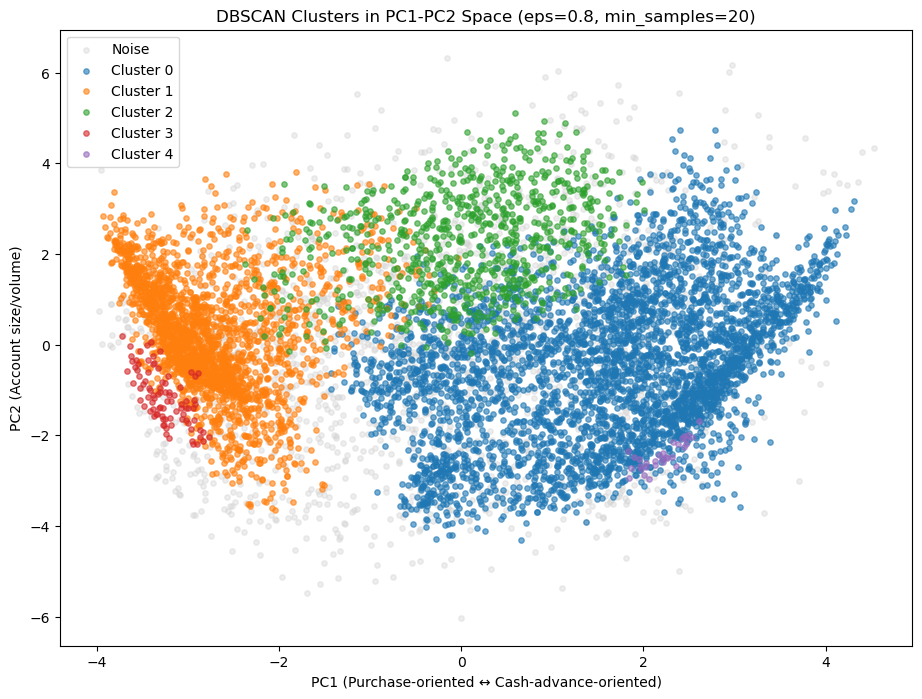

In [73]:
plt.figure(figsize=(11, 8))

# Plot noise points first (gray, background)
noise_mask = labels_final == -1
plt.scatter(df_pca.loc[noise_mask, 'PC1'], df_pca.loc[noise_mask, 'PC2'],
            c='lightgray', s=15, alpha=0.4, label='Noise')

# Plot each cluster with a distinct color
for cluster_id in sorted(set(labels_final)):
    if cluster_id == -1:
        continue
    mask = labels_final == cluster_id
    plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                s=15, alpha=0.6, label=f'Cluster {cluster_id}')

plt.xlabel('PC1 (Purchase-oriented ↔ Cash-advance-oriented)')
plt.ylabel('PC2 (Account size/volume)')
plt.title('DBSCAN Clusters in PC1-PC2 Space (eps=0.8, min_samples=20)')
plt.legend()
plt.show()